## Notebook to experiment with bias correction
- ERA5
- CMIP
- GRDC

for now 1d 

-----------------
#### To Do

- cumulative dist function
- map between ERA5 and CMIP
- make .py function
- test?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ewatercycle.observation.grdc import get_grdc_data
from scipy.interpolate import interp1d

In [2]:
grdc_kerki = get_grdc_data(
    2617110, "1953-01-01T00:00Z", "2020-01-01T00:00Z", data_home="../../data/GRDC/Daily"
)

In [3]:
hbv_dir = Path("../../model_runs/HBV/ensemble_full")


file_mmd = hbv_dir / "HBV_Kerki_ensemble_5020_mmd.nc"
file_m3s = hbv_dir / "HBV_Kerki_ensemble_5020_m3s.nc"
file_param = hbv_dir / "HBV_Kerki_ensemble_5020_params.nc"


hbv_mmd = xr.open_dataset(file_mmd, engine="netcdf4")
hbv_m3s = xr.open_dataset(file_m3s, engine="netcdf4")
hbv_params = xr.open_dataset(file_param, engine="netcdf4")

hbv_mmd.close()
hbv_m3s.close()
hbv_params.close()

hbv_mmd_d = hbv_mmd.resample(time="1D").mean()
hbv_m3s_d = hbv_m3s.resample(time="1D").mean()

In [4]:
hbv_CMIP_dir = Path("../../model_runs/HBV/CMIP_runs")

file_mmd_cmip = hbv_CMIP_dir / "HBV_Kerki_ensemble_CMIP_historical_mmd.nc"
file_m3s_cmip = hbv_CMIP_dir / "HBV_Kerki_ensemble_CMIP_historical_m3s.nc"
file_param_cmip = hbv_CMIP_dir / "HBV_Kerki_ensemble_CMIP_historical_params.nc"


hbv_mmd_cmip = xr.open_dataset(file_mmd_cmip, engine="netcdf4")
hbv_m3s_cmip = xr.open_dataset(file_m3s_cmip, engine="netcdf4")
hbv_params_cmip = xr.open_dataset(file_param_cmip, engine="netcdf4")

hbv_mmd_cmip.close()
hbv_m3s_cmip.close()
hbv_params_cmip.close()

hbv_mmd_d_cmip = hbv_mmd_cmip.resample(time="1D").mean()
hbv_m3s_d_cmip = hbv_m3s_cmip.resample(time="1D").mean()

In [5]:
da_ERA5 = hbv_m3s_d["discharge"].sel(
    time=slice("1953-01-01", "2014-12-31")
)  # .sel(particle=[246,218,70,211,138])
da_CMIP = hbv_m3s_d_cmip["discharge"].sel(
    time=slice("1953-01-01", "2014-12-31")
)  # .sel(particle=[246,218,70,211,138])
# particle=[70,57,187,44,133])

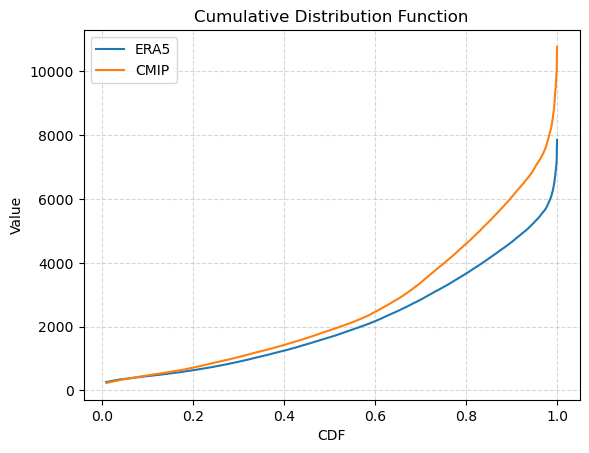

In [21]:
def cumulative_distribution(data, bins=100):
    """
    Compute the cumulative distribution function (CDF) of a dataset.

    Parameters
    ----------
    data : array-like
        1D array of numeric values.
    bins : int
        Number of bins to use for histogram approximation.

    Returns
    -------
    x : ndarray
        Sorted bin centers or data values.
    cdf : ndarray
        Cumulative probabilities corresponding to x.
    """
    # Remove NaNs
    data = np.asarray(data)
    data = data[~np.isnan(data)]

    # Histogram approximation
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    cdf = np.cumsum(counts) * np.diff(bin_edges)  # approximate integral
    x = bin_edges[1:]  # use right edges for plotting

    return x, cdf


# Example usage
nr_particle = 3
data1 = da_ERA5.sel(particle=nr_particle).values
data2 = da_CMIP.sel(particle=nr_particle).values

x_ERA5, cdf_ERA5 = cumulative_distribution(data)
x_CMIP, cdf_CMIP = cumulative_distribution(data2)


plt.plot(cdf_ERA5, x_ERA5, label="ERA5")
plt.plot(cdf_CMIP, x_CMIP, label="CMIP")
plt.ylabel("Value")
plt.xlabel("CDF")
plt.legend()
plt.title("Cumulative Distribution Function")
plt.grid(linestyle="--", alpha=0.5)
plt.show()

In [22]:
# 1. Interpolate the CMIP CDF: value -> cumulative probability
cmip_cdf_func = interp1d(x_CMIP, cdf_CMIP, bounds_error=False, fill_value=(0, 1))

# 2. Interpolate the ERA5 inverse CDF: probability -> value
era5_icdf_func = interp1d(cdf_ERA5, x_ERA5, bounds_error=False, fill_value="extrapolate")

# 3. Apply bias correction to CMIP data
data2_corrected = era5_icdf_func(cmip_cdf_func(data2))

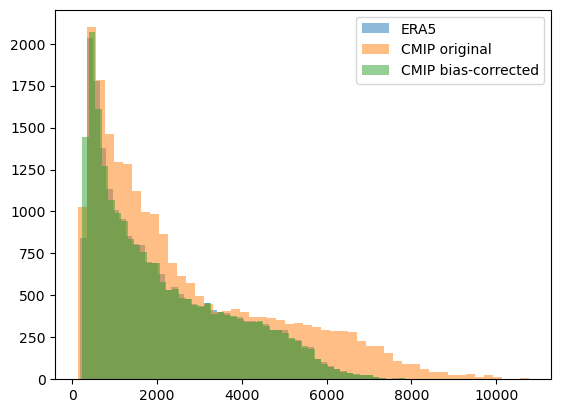

In [26]:
import matplotlib.pyplot as plt

plt.hist(data, bins=50, alpha=0.5, label="ERA5")
plt.hist(data2, bins=50, alpha=0.5, label="CMIP original")
plt.hist(data2_corrected, bins=50, alpha=0.5, label="CMIP bias-corrected")
plt.legend()
plt.show()

In [27]:
from scipy.interpolate import interp1d


def build_qm_func(x_model, cdf_model, x_ref, cdf_ref):
    """
    Returns a function that maps model values to bias-corrected reference values.
    """
    model_cdf_func = interp1d(x_model, cdf_model, bounds_error=False, fill_value=(0, 1))
    ref_icdf_func = interp1d(cdf_ref, x_ref, bounds_error=False, fill_value="extrapolate")

    def correct(model_values):
        return ref_icdf_func(model_cdf_func(model_values))

    return correct

In [28]:
qm_func = build_qm_func(x_CMIP, cdf_CMIP, x_ERA5, cdf_ERA5)

In [33]:
CMIP_future_corrected = qm_func(da_CMIP.sel(particle=5).values)

In [34]:
CMIP_future_corrected

array([ 733.70443512,  726.43764939,  719.90503244, ..., 1242.22433354,
       1227.58449021, 1212.68005594])

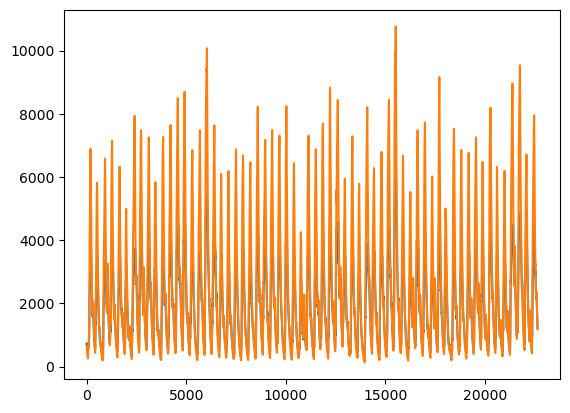

In [35]:
plt.plot(CMIP_future_corrected)
plt.plot(da_CMIP.sel(particle=3))

In [ ]:
data1 = CMIP_future_corrected
data2 = da_CMIP.sel(particle=3).values

x_ERA5, cdf_ERA5 = cumulative_distribution(data)
x_CMIP, cdf_CMIP = cumulative_distribution(data2)


import matplotlib.pyplot as plt

plt.plot(cdf_ERA5, x_ERA5, label="CMIP_future_corrected")
plt.plot(cdf_CMIP, x_CMIP, label="CMIP")
plt.ylabel("Value")
plt.xlabel("CDF")
plt.legend()
plt.title("Cumulative Distribution Function")
plt.grid(linestyle="--", alpha=0.5)
plt.show()

AttributeError: 'function' object has no attribute 'values'